In [1]:
import pandas as pd

import joblib

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

In [2]:
df = pd.read_csv(
    "../data/processed/cleaned_news.csv"
)

df.dropna(inplace=True)

df.head()

,clean_content,label
0,ben stein call th circuit court commit coup ta...,0
1,trump drop steve bannon nation secur council w...,1
2,puerto rico expect u lift jone act ship restri...,1
3,oop trump accident confirm leak isra intellig ...,0
4,donald trump head scotland reopen golf resort ...,1


In [3]:
model = joblib.load(
    "../models/fake_news_model.pkl"
)


vectorizer = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

In [4]:
X = df["clean_content"]

y = df["label"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
X_test_vector = vectorizer.transform(
    X_test
)

In [6]:
prediction = model.predict(
    X_test_vector
)

In [7]:
print(
    classification_report(
        y_test,
        prediction
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4644
           1       0.99      0.99      0.99      4334

    accuracy                           0.99      8978
   macro avg       0.99      0.99      0.99      8978
weighted avg       0.99      0.99      0.99      8978



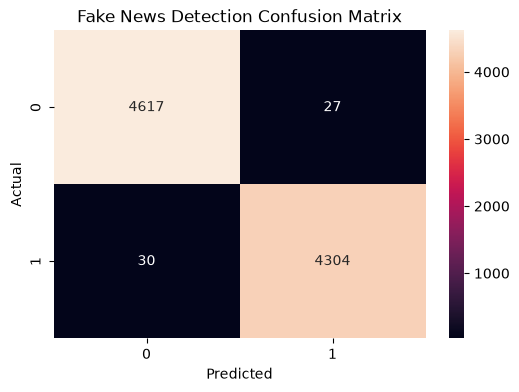

In [8]:
cm = confusion_matrix(
    y_test,
    prediction
)


plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel("Predicted")

plt.ylabel("Actual")


plt.title(
    "Fake News Detection Confusion Matrix"
)


plt.show()

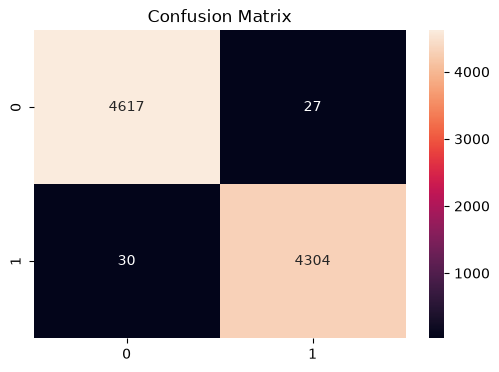

In [9]:
plt.figure(figsize=(6,4))


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.title(
    "Confusion Matrix"
)


plt.savefig(
    "../reports/figures/confusion_matrix.png"
)

In [10]:
report = classification_report(
    y_test,
    prediction
)


with open(
    "../reports/model_report.md",
    "w"
) as file:
    
    file.write(report)